In [ ]:
from pathlib import Path
import os
import re
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import sys 
sys.path.append("../")

from checkpoint import CheckPoint
from generate_data import ALL_TRANSFORMATIONS

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Overlap check between training and new alphabets datasets
- check that there training datasets and dataset containing the new alphabets share no permuted alphabets:

In [42]:
# check that training alphabets have no overlap with new alphabets:
df20 = pd.read_csv("../data/all_transformations_study1_copy_perm20/train.csv")
df40 = pd.read_csv("../data/all_transformations_study1_copy_perm40/train.csv")
df60 = pd.read_csv("../data/all_transformations_study1_copy_perm60/train.csv")
df80 = pd.read_csv("../data/all_transformations_study1_copy_perm80/train.csv")
df100 = pd.read_csv("../data/all_transformations_study1_copy_perm100/train.csv")
df140 = pd.read_csv("../data/all_transformations_study1_copy_perm140/train.csv")
df200 = pd.read_csv("../data/all_transformations_study1_copy_perm200/train.csv")
df400 = pd.read_csv("../data/all_transformations_study1_copy_perm400/train.csv")

all_training_alphabets = set(
    list(df20.alphabet.unique()) + 
    list(df40.alphabet.unique()) + 
    list(df60.alphabet.unique()) + 
    list(df80.alphabet.unique()) +
    list(df100.alphabet.unique()) +
    list(df140.alphabet.unique()) +
    list(df200.alphabet.unique()) +
    list(df400.alphabet.unique())
    )

df_new_alphs = pd.read_csv("../data/all_transformations_study1_new_alphabets/test.csv")
# only overlapping alphabet should be the standard alphabet:
all_training_alphabets & set(df_new_alphs.alphabet.unique())

{'a b c d e f g h i j k l m n o p q r s t u v w x y z'}

In [7]:
levenshtein_distances_by_dataset = []
for training_alphabets in [df20, df40, df60, df80, df100, df140, df200, df400]:
    min_levenshtein_distances = []
    for new_alph in df_new_alphs.alphabet.unique():
        min_levenshtein_dist = 1_000_000 # initialize with arbitrarily large number
        for train_alph in training_alphabets.alphabet.unique():
            levenshtein_dist = nltk.edit_distance(train_alph, new_alph)
            if levenshtein_dist < min_levenshtein_dist:
                min_levenshtein_dist = levenshtein_dist
        min_levenshtein_distances.append(min_levenshtein_dist)
    levenshtein_distances_by_dataset.append({
        "mean": np.mean(min_levenshtein_distances),
        "sd": np.std(min_levenshtein_distances)
    })

In [8]:
for perm_alphs, levenshtein_dist in zip(all_training_alphabets, levenshtein_distances_by_dataset):
    print(f"Training Dataset (with {perm_alphs} alphabets): Average minimum Levenshtein distance to new alphabets: {levenshtein_dist["mean"]:.2f} (sd: {levenshtein_dist["sd"]:.2f})")

Training Dataset (with j b c l e f g h i z k d m n o p q r s t u v w x y a alphabets): Average minimum Levenshtein distance to new alphabets: 8.52 (sd: 6.64)
Training Dataset (with a j p d e u g h i l k z m n o c x r s t f v w q y b alphabets): Average minimum Levenshtein distance to new alphabets: 8.38 (sd: 6.54)
Training Dataset (with d b c m e a s h i j x l t n o p q r g f u k w v y z alphabets): Average minimum Levenshtein distance to new alphabets: 8.24 (sd: 6.61)
Training Dataset (with a w c d e n g z i j k f m y t p q r s h u v o x b l alphabets): Average minimum Levenshtein distance to new alphabets: 8.19 (sd: 6.61)
Training Dataset (with a b g d l f h e y j k t s n o p q r c i u v w x m z alphabets): Average minimum Levenshtein distance to new alphabets: 8.05 (sd: 6.48)
Training Dataset (with k b c d e f g h i j a l m n o p q r s t u v w x y z alphabets): Average minimum Levenshtein distance to new alphabets: 7.86 (sd: 6.40)
Training Dataset (with s a c l e f g o i j k b m n d

### Helper function for bootstrapped confidence intervals

In [11]:
def bootstrapped_confint(arr, n_samples:int = 10_000, alpha:float=0.05):
    # sample with replacement n_samples times and take the mean of each sample:
    samples = np.array([np.mean(np.random.choice(arr, size=len(arr), replace=True)) for _ in range(n_samples)])
    # sort means in ascending order:
    samples.sort()
    # get bootstrapped confidence interval boundaries:
    confint_low = samples[int(n_samples * (alpha / 2))]
    confint_upp = samples[int(n_samples * (1 - alpha / 2))]
    return confint_low, confint_upp

## Figures & Tables

In [22]:
all_accs = pd.read_csv("tables/all_evaluations.csv")
all_accs

,filename,copy,batching method,num. seen alphabets in training,seen_transform,new_transform,alphabets
0,MLC_batchrand_dallstudy1_perm20_nep20_matched.pt,False,random,20,0.630000,0.110000,seen
1,MLC_batchrand_dallstudy1_perm20_nep20_matched.pt,False,random,20,0.257434,0.042107,new
2,MLC_batchbyboth_dallstudy1_perm20_nep20_matche...,False,transformation_alphabet,20,0.614000,0.103000,seen
3,MLC_batchbyboth_dallstudy1_perm20_nep20_matche...,False,transformation_alphabet,20,0.267610,0.040569,new
4,MLC_batchbytrans_dallstudy1_perm20_nep20_match...,False,transformation,20,0.648000,0.124000,seen
...,...,...,...,...,...,...,...
227,MLC_batchalph_dallstudy1_copy_perm60_nep20.pt,True,alphabet,60,0.567340,0.053067,new
228,MLC_batchrand_dallstudy1_copy_perm20_nep20_rep...,True,random,20,0.899000,0.097000,seen
229,MLC_batchrand_dallstudy1_copy_perm20_nep20_rep...,True,random,20,0.342821,0.038262,new
230,MLC_batchalph_dallstudy1_copy_perm40_nep20_rep...,True,alphabet,40,0.951000,0.134000,seen


### Main Results Table (short)

In [23]:
accs_main = all_accs[all_accs["num. seen alphabets in training"].isin([20,200])]

In [26]:
# 1. Group by copy and num. seen alphabets in training, pivot on alphabets
pivot_df = accs_main.pivot_table(
    index=["copy", "num. seen alphabets in training"],
    columns="alphabets",
    values=["seen_transform", "new_transform"],
    aggfunc="mean"
)

# Convert to percentages (multiply by 100)
pivot_df = pivot_df * 100

# Reorder columns explicitly: seen_transform (seen, new), new_transform (seen, new)
col_order = [
    ('seen_transform', 'seen'),
    ('seen_transform', 'new'),
    ('new_transform', 'seen'),
    ('new_transform', 'new')
]
pivot_df = pivot_df[col_order]

pivot_df.round(1)

seen_transform       new_transform      
alphabets                                       seen   new          seen   new
copy  num. seen alphabets in training                                         
False 20                                        60.9  26.5          10.2   3.2
True  20                                        91.0  33.1          10.2   3.9
      200                                       96.7  93.9          13.1  12.3

In [27]:
# Convert to latex standard format
latex_str = pivot_df.round(1).to_latex(index=True)
print(latex_str)

\begin{tabular}{llrrrr}
\toprule
 &  & \multicolumn{2}{r}{seen_transform} & \multicolumn{2}{r}{new_transform} \\
 & alphabets & seen & new & seen & new \\
copy & num. seen alphabets in training &  &  &  &  \\
\midrule
False & 20 & 60.900000 & 26.500000 & 10.200000 & 3.200000 \\
\cline{1-6}
\multirow[t]{2}{*}{True} & 20 & 91.000000 & 33.100000 & 10.200000 & 3.900000 \\
 & 200 & 96.700000 & 93.900000 & 13.100000 & 12.300000 \\
\cline{1-6}
\bottomrule
\end{tabular}



### Main Results Table (long)

In [33]:
def format_score_with_confidence_interval(scores_array: np.ndarray) -> str:
    if len(scores_array) == 0:
        return "-"

    percentage_scores = np.array(scores_array) * 100
    mean_score = np.mean(percentage_scores)

    if len(percentage_scores) > 1:
        lower_bound, upper_bound = bootstrapped_confint(percentage_scores)
    else:
        lower_bound, upper_bound = mean_score, mean_score

    return f"{mean_score:.1f} [{lower_bound:.1f}, {upper_bound:.1f}]"


def build_summary_dataframe(experiment_df: pd.DataFrame) -> pd.DataFrame:
    grouping_columns = [
        "copy",
        "num. seen alphabets in training",
        "batching method",
    ]

    column_multi_index = pd.MultiIndex.from_tuples(
        [
            ("seen_transform", "seen"),
            ("seen_transform", "new"),
            ("new_transform", "seen"),
            ("new_transform", "new"),
        ],
        names=["transform", "alphabets"],
    )

    grouped_experiments = experiment_df.groupby(grouping_columns)
    summary_records = {}

    for group_key, experiment_subset in grouped_experiments:
        cell_values = {}
        for transform_metric, alphabet_type in column_multi_index:
            scores_array = experiment_subset[
                experiment_subset["alphabets"] == alphabet_type
            ][transform_metric].dropna().values

            cell_values[(transform_metric, alphabet_type)] = (
                format_score_with_confidence_interval(scores_array)
            )

        summary_records[group_key] = cell_values

    formatted_summary_df = pd.DataFrame.from_dict(
        summary_records, orient="index"
    )
    formatted_summary_df.index = pd.MultiIndex.from_tuples(
        formatted_summary_df.index, names=grouping_columns
    )
    formatted_summary_df.columns = column_multi_index

    return formatted_summary_df


summary_long = build_summary_dataframe(accs_main)
summary_long

transform                                                          seen_transform  \
alphabets                                                                    seen   
copy  num. seen alphabets in training batching method                               
False 20                              alphabet                  56.3 [55.5, 57.6]   
                                      random                    65.3 [55.9, 79.2]   
                                      transformation            64.5 [63.2, 65.6]   
                                      transformation_alphabet   57.6 [55.2, 59.8]   
True  20                              alphabet                  90.2 [89.7, 90.7]   
                                      random                    91.5 [90.4, 92.6]   
                                      transformation            92.6 [88.9, 96.0]   
                                      transformation_alphabet   89.2 [88.2, 89.8]   
      200                             alphabet                 95.8 [87.3, 100.0]   
                                      random                    97.7 [93.7, 99.9]   

transform                                                                         \
alphabets                                                                    new   
copy  num. seen alphabets in training batching method                              
False 20                              alphabet                 27.8 [27.8, 27.9]   
                                      random                   27.7 [26.3, 29.8]   
                                      transformation           23.3 [23.0, 23.7]   
                                      transformation_alphabet  27.2 [26.5, 27.9]   
True  20                              alphabet                 32.4 [31.2, 33.3]   
                                      random                   33.7 [32.7, 34.8]   
                                      transformation           31.4 [27.2, 35.0]   
                                      transformation_alphabet  34.3 [32.0, 36.4]   
      200                             alphabet                 93.4 [80.6, 99.9]   
                                      random                   94.5 [86.3, 99.4]   

transform                                                          new_transform  \
alphabets                                                                   seen   
copy  num. seen alphabets in training batching method                              
False 20                              alphabet                  10.2 [9.6, 10.9]   
                                      random                     9.4 [6.9, 12.5]   
                                      transformation           13.6 [11.9, 15.8]   
                                      transformation_alphabet     7.6 [6.0, 9.3]   
True  20                              alphabet                  10.0 [9.6, 10.5]   
                                      random                    10.1 [9.9, 10.2]   
                                      transformation            10.7 [9.7, 11.8]   
                                      transformation_alphabet   10.1 [9.2, 11.4]   
      200                             alphabet                  15.8 [8.7, 22.6]   
                                      random                    10.4 [8.6, 12.0]   

transform                                                                        
alphabets                                                                   new  
copy  num. seen alphabets in training batching method                            
False 20                              alphabet                   3.6 [3.2, 4.1]  
                                      random                     3.2 [2.3, 4.2]  
                                      transformation             3.2 [2.8, 3.6]  
                                      transformation_alphabet    2.7 [2.1, 3.5]  
True  20                              alphabet                   3.8 [3.5, 4.1]  
                                      random        

In [34]:
print(summary_dataframe.to_latex())

\begin{tabular}{lllllll}
\toprule
 &  & transform & \multicolumn{2}{r}{seen_transform} & \multicolumn{2}{r}{new_transform} \\
 &  & alphabets & seen & new & seen & new \\
copy & num. seen alphabets in training & batching method &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{False} & \multirow[t]{4}{*}{20} & alphabet & 56.3 [55.5, 57.5] & 27.8 [27.8, 27.9] & 10.2 [9.6, 10.9] & 3.6 [3.2, 4.1] \\
 &  & random & 65.3 [55.9, 79.4] & 27.7 [26.3, 29.9] & 9.4 [6.9, 12.5] & 3.2 [2.3, 4.2] \\
 &  & transformation & 64.5 [63.1, 65.6] & 23.3 [23.0, 23.8] & 13.6 [11.9, 15.7] & 3.2 [2.8, 3.6] \\
 &  & transformation_alphabet & 57.6 [55.2, 59.8] & 27.2 [26.5, 27.9] & 7.6 [6.0, 9.3] & 2.7 [2.1, 3.5] \\
\cline{1-7} \cline{2-7}
\multirow[t]{6}{*}{True} & \multirow[t]{4}{*}{20} & alphabet & 90.2 [89.7, 90.7] & 32.4 [31.2, 33.3] & 10.0 [9.6, 10.5] & 3.8 [3.5, 4.1] \\
 &  & random & 91.5 [90.4, 92.6] & 33.7 [32.6, 34.8] & 10.1 [9.9, 10.2] & 3.9 [3.8, 4.0] \\
 &  & transformation & 92.6 [88.9, 96.0] & 31.4 [27.

### Figure Generalization by num. training alphabets

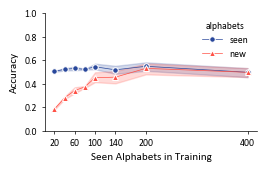

In [15]:
# Figure 4 (joint, aggregated over all transformations)
my_markers = {"seen": "o", "new": "^"}
my_colors = ["#28479bff", "#ff4f44ff"] 

plt.style.use("./figures_stylesheet.mplstyle")
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(2.75, 1.8))
_ = sns.lineplot(all_accs[all_accs["copy"]==True], 
                 x="num. seen alphabets in training", y="all transform.", 
                 hue="alphabets", 
                 ax=ax, 
                 markers=my_markers,
                 dashes=False,
                 style="alphabets",
                 errorbar=bootstrapped_confint,
                 palette=my_colors
                 )
_ = ax.set_xticks([20, 60, 100, 140, 200, 400])
_ = ax.set_xlabel("Seen Alphabets in Training")

_ = ax.set_ylim((0,1))
_ = ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
_ = ax.set_ylabel("Accuracy")


_ = fig.tight_layout(pad=1)
plt.savefig("../figures/acc_by_num_train_alphabets_aggr.svg", format="svg", transparent=True)

## Accuracy by transformation (Table 2)

- Computed for models trained with 200 permuted alphabets including copy tasks with batching method = alphabet

In [ ]:
num_alph_pattern = r'perm(\d+)_'
parent_dir = Path("../models/num_permuted_alphabets")
all_alph_runs_200 = []
for run in os.listdir(parent_dir):
    perm = re.search(num_alph_pattern, run)
    num_perm_alphs = int(perm.group(1))
    if "alph" in run and num_perm_alphs == 200:
        cp = CheckPoint.from_pt(parent_dir / run)
        all_alph_runs_200.append(cp)

In [ ]:
all_acc_by_trans = pd.DataFrame()
for i, train_run in enumerate(all_alph_runs_200):
    acc_by_trans = pd.DataFrame({
        "transformation": train_run.val_acc_hist[-1].keys(), 
        "accuracy": train_run.val_acc_hist[-1].values()
    })
    all_acc_by_trans = pd.concat([all_acc_by_trans, acc_by_trans])

# remove aggregate accuracies:
all_acc_by_trans = all_acc_by_trans[~all_acc_by_trans["transformation"].isin(["epoch", "overall", "copy", "noncopy", "in", "out-of"])]

In [57]:
transformation_map = {
    "extend_sequence": "Ext",
    "succ": "Succ",
    "pred": "Pred",
    "remove_redundant": "RmRed",
    "fix_alphabetic_seq": "Fix",
    "sort": "Sort",
    "sort_group": "Sort + Gp",
    "rr_interleave": "RmRed + IL",
    "rr_succ": "RmRed + Succ",
    "fix_extend": "Fix + Ext",
    "rr_sort": "RmRed + Sort",
    "extend_pred": "Ext + Pred",
    "fix_interleave": "Fix + IL",
    "extend_group": "Ext + Gp",
    "extend_extend_succ": "Ext + Ext + Succ",
    "fix_pred_succ": "Fix + Pred + Succ",
    "reverse": "Rev",
    "shift": "Shift",
    "replicate": "Rep",
}

# sort by order as presented in the paper
trans_order = [trans["transformation"] for trans in ALL_TRANSFORMATIONS.values()][:-1]

# map transformation to generalization types (seen, compositional, novel)
gen_id2label = {0: "seen",
                2: "comp.",
                3: "novel"}
gen_type = {trans["transformation"]: gen_id2label[trans["generalization_type"]] for trans in ALL_TRANSFORMATIONS.values()}

table_acc_by_trans = pd.DataFrame(columns=["Type", "Transformation", "Accuracy (%)"])
for i, transform in enumerate(trans_order, 1):
    transform_rows = all_acc_by_trans[all_acc_by_trans["transformation"]==transform]
    mean_trans = transform_rows["accuracy"].mean()
    ci_low, ci_upp = bootstrapped_confint(transform_rows["accuracy"].values)
    new_row = pd.DataFrame({
        "Type": gen_type[transform], 
        "Transformation": transformation_map[transform], 
        "Accuracy (%)": round(mean_trans * 100, 1)
    }, index=[i])
    table_acc_by_trans = pd.concat([table_acc_by_trans, new_row])

table_acc_by_trans

C:\Users\13579681\AppData\Local\Temp\ipykernel_22924\42459855.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  table_acc_by_trans = pd.concat([table_acc_by_trans, new_row])


,Type,Transformation,Accuracy (%)
1,seen,Ext,97.5
2,seen,Succ,97.1
3,seen,Pred,93.9
4,seen,RmRed,100.0
5,seen,Fix,89.5
6,seen,Sort,95.7
7,seen,Sort + Gp,95.6
8,seen,RmRed + IL,100.0
9,seen,RmRed + Succ,96.8
10,seen,Fix + Ext,91.2


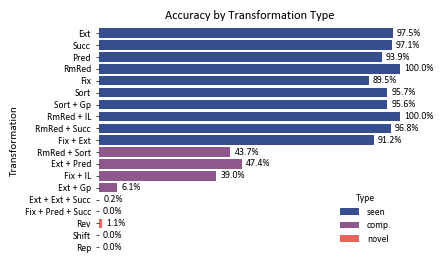

In [58]:
plt.style.use("figures_stylesheet.mplstyle")

fig, ax = plt.subplots(1, 1, figsize=(4.1, 2.3))
# 1. Define specific markers for your 'model type' categories
# Ensure the keys match the unique values in your "model type" column
my_colors = ["#28479bff", "#9a4d94ff", "#ff4f44ff"] 
sns.barplot(
    data=table_acc_by_trans, 
    y="Transformation", 
    x="Accuracy (%)", 
    hue="Type", 
    ax=ax,
    palette=my_colors,
)

for container in ax.containers:
    ax.bar_label(
        container, 
        fmt='%.1f%%',
        padding=3,
        fontsize=7, 
        color='black'
    )

ax.set_xlim((0, 100))
ax.set_xlabel("")
ax.set_ylabel("Transformation")
ax.spines['bottom'].set_visible(False)
ax.get_xaxis().set_visible(False) 
ax.spines['left'].set_visible(False)
ax.set_title("Accuracy by Transformation Type")
plt.tight_layout(pad=-0.5)
plt.savefig("../figures/acc_by_transformation.svg", format="svg", transparent=True)
plt.show()